In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Simulate the data

## Healthy signal

In [ ]:
def X(t,n,A,a,f,sigma):
    x = np.zeros_like(t)
    for i in range(1,n+1):
        x += A*np.power(a,i-1)*np.sin(2*np.pi*f*i*t)
    x += sigma*np.random.normal(0,1,len(t))
    return x

## Faulty signal

In [30]:
def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low,high],btype = 'band')
    return lfilter(b,a,data)

def X_faulty(t, n, A, a, f, sigma, fs):
    x = np.zeros_like(t)
    for i in range(1, n+1):
        x += A*np.power(a,i-1)*np.sin(2*np.pi*f*i*t)
    
    # wygenerować biały szum Gaussa
    noise = np.random.normal(0,1,len(t))
    
    # przepuścić szum przez filtr pasmowy (1000 - 6000 Hz)
    noise_band = bandpass_filter(noise, fs, 1000, 6000)

    # Wygenerować sygnał impulsowy z częstotliwością 13Hz
    f_fault = 13
    n_harm = 15 #zmienimy potem na 6
    impulse_train = np.zeros_like(t)
    for k in range(1, n_harm + 1):
        impulse_train += np.sin(2* np.pi *f_fault*k*t)
    
    # Normalizacja impulsów
    impulse_train = impulse_train / np.max(np.abs(impulse_train))

    # Zmodulować amplitudowo szum filtrowany
    noise_faulty = noise_band*(1 + impulse_train)

    # Dodać sygnał deterministyczny (sumę sinusów)
    x = x + sigma* noise_faulty

    return x

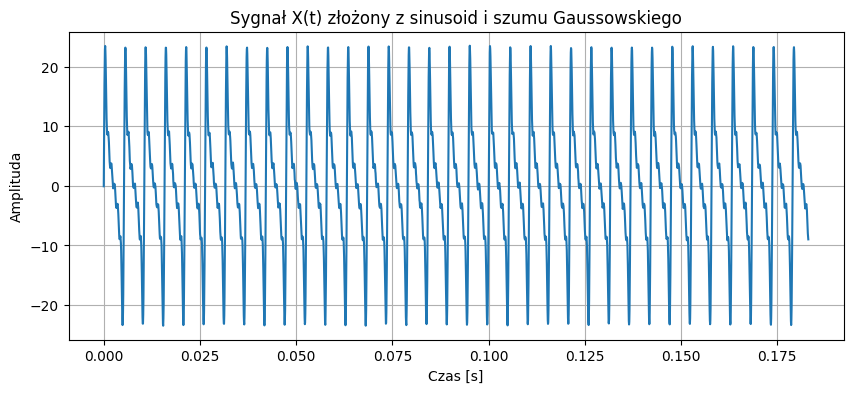

In [20]:
#dane

n = 6
A = 10
a = 0.75
f = 190
sigma = 0.1
fs = 16384
T = 2.5
t = np.linspace(0,T,int(fs*T), endpoint = False)

signal = X(t,n,A,a,f,sigma)

N= 3000 #wycinek

# Rysunek
plt.figure(figsize=(10, 4))
plt.plot(t[:N], signal[:N])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Sygnał X(t) złożony z sinusoid i szumu Gaussowskiego")
plt.grid(True)
plt.show()


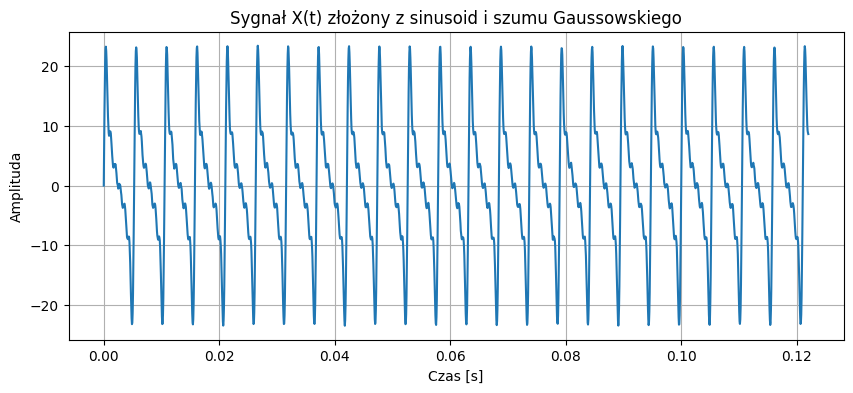

In [28]:
signal_faulty = X_faulty(t,n,A,a,f,sigma,fs)

N= 2000 #wycinek

# Rysunek
plt.figure(figsize=(10, 4))
plt.plot(t[:N], signal_faulty[:N])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Sygnał X(t) złożony z sinusoid i szumu Gaussowskiego")
plt.grid(True)
plt.show()

## Szumy

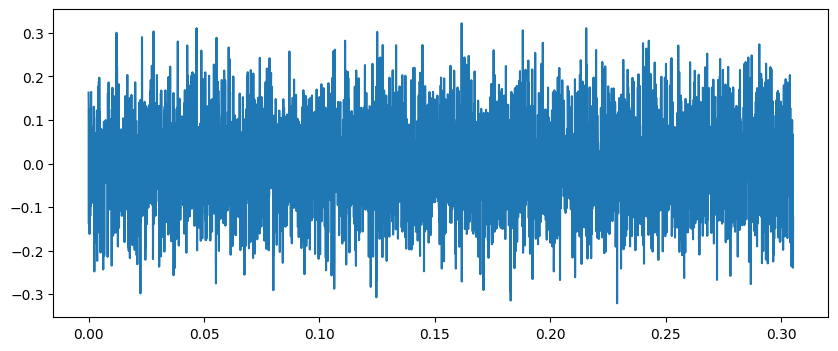

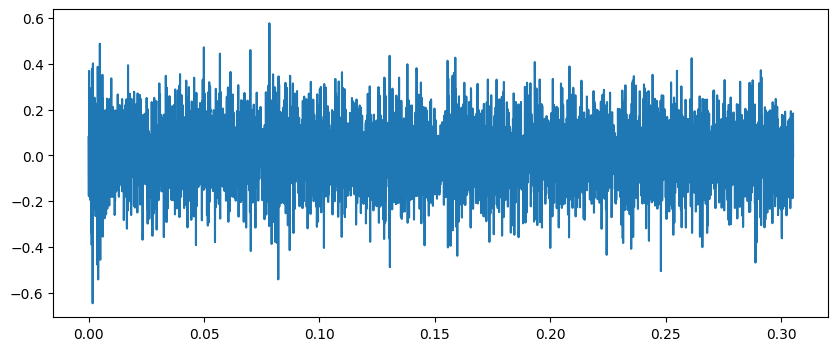

In [57]:
fs = 16384
T = 2.5
t = np.linspace(0,T,int(fs*T), endpoint = False)
wn = sigma* np.random.normal(0,1,len(t))

N =5000

plt.figure(figsize=(10, 4))
plt.plot(t[:N], wn[:N])


# wygenerować biały szum Gaussa
noise_faulty = sigma*np.random.normal(0,1,len(t))

# przepuścić szum przez filtr pasmowy (1000 - 6000 Hz)
noise_band = bandpass_filter(noise_faulty, fs, 1000, 6000)

# Wygenerować sygnał impulsowy z częstotliwością 13Hz
f_fault = 13
n_harm = 10 #zmienimy potem na 6
impulse_train = np.zeros_like(t)
for k in range(1, n_harm + 1):
    impulse_train += np.sin(2* np.pi *f_fault*k*t)

# Normalizacja impulsów
impulse_train = impulse_train / np.max(np.abs(impulse_train))

# Zmodulować amplitudowo szum filtrowany
noise_faulty += noise_band*(1 + impulse_train)

plt.figure(figsize=(10, 4))
plt.plot(t[:N], noise_faulty[:N])